In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics.pairwise import haversine_distances
from enum import Enum
from tqdm import tqdm

from data_visualisation import *

# Data Handling and Preprocessing

In [2]:
def import_data(data : str) -> pd.DataFrame:
    if not os.path.exists(data):
        print("Error: file does not exist.")
        return None
    df = pd.read_csv(data)
    return df

In [3]:
def preprocess_data (df: pd.DataFrame, min_population : float =1e5) -> pd.DataFrame:
    df = df.dropna()
    df = df[df['country'] == 'India']
    df = df[df['population'] >= min_population]
    df = df[df['lng'].between(65, 100) & df['lat'].between(5, 40)]
    df = df.drop_duplicates(subset=['city'])
    df = df[['city', 'population', 'country', 'lat', 'lng']].copy()
    df = df.reset_index(drop=True)
    df.insert(0, 'city_id', range(len(df)))
    
    return df

In [4]:
data_path = "data/indiacities.csv"

df = import_data(data_path)
df = preprocess_data(df, 1e5)
df.to_csv("data/cities_data.csv", index = False)

# Cost Calculations

### Constants

In [5]:
class TransportMode(Enum):
    ROAD = "road"
    RAIL = "rail"
    AIR = "air"
    
## Cost of travel when transporting freight by different modes (INR/tonne-km)
TRAVEL_COSTS_TONNE_KM = {
    TransportMode.ROAD: 3.6,
    TransportMode.RAIL: 1.6,
    TransportMode.AIR: 18,
}

## CO2 emissions when transporting freight by different modes (gm CO2/tonne-km)
CO2_EMISSIONS_TONNE_KM = {
    TransportMode.ROAD: 101,
    TransportMode.RAIL: 11.5,
    TransportMode.AIR: 610,
}

TRAVEL_SPEEDS = {
    TransportMode.ROAD: 30,
    TransportMode.RAIL: 35,
    TransportMode.AIR: 450,
}

In [467]:
COST_OF_CARBON_KG = 4.42    # Median carbon shadow price in major corporations $49/tonne = INR 4.42/kg CO2
CONSUMPTION_RATE = 2.78   # Average parcels per person
AVG_WEIGHT_PER_UNIT_KG = 1.5 # Typical Amazon parcel avg weight
TIME_VALUE_KG_HOUR = 2.0
AOV_INDIA = 9600.0
CARRYING_RATE = 0.20
CARRYING_COST_PARCEL_HOUR = AOV_INDIA*CARRYING_RATE/8760
TIME_VALUE_KG_HOUR = CARRYING_COST_PARCEL_HOUR*AVG_WEIGHT_PER_UNIT_KG
SHIPMENT_WEIGHT_PER_PERSON = CONSUMPTION_RATE*AVG_WEIGHT_PER_UNIT_KG
WAREHOUSE_LAND_AREA = 2.5e5
LAND_RENT_SQFT_YEAR = 24*12
OPEX_RATIO = 0.5
WAREHOUSE_COST = WAREHOUSE_LAND_AREA*LAND_RENT_SQFT_YEAR*(1+OPEX_RATIO)

### Cost Functions

In [7]:
def get_distance_matrix(df: pd.DataFrame) -> pd.DataFrame:

    lat = df["lat"].to_numpy()
    lng = df["lng"].to_numpy()
    cities = df["city"].to_numpy()
    
    coords = np.column_stack([np.radians(lat), np.radians(lng)])
    d_mat = haversine_distances(coords)
    
    # Convert radians to km (Earth radius = 6371 km)
    d_mat = d_mat * 6371

    return pd.DataFrame(d_mat, index=cities, columns=cities)

In [8]:
def calc_fuel_cost(distance_km: float, 
                   mode: TransportMode, 
                   weight_kg: float, 
                   travel_costs_tonne_km: dict = TRAVEL_COSTS_TONNE_KM) -> float:
    
    tonnes = weight_kg/1000
    linear_cost = travel_costs_tonne_km[mode]
    if mode == TransportMode.AIR:
        a_takeoff = 6500.0
        k_takeoff = 0.008
        
        return tonnes * (a_takeoff * (1 - np.exp(-k_takeoff * distance_km)) + linear_cost * distance_km)
    else:
        return linear_cost * tonnes * distance_km

In [9]:
def calc_carbon_cost(distance_km: float, 
                     mode: TransportMode, 
                     weight_kg: float, 
                     emissions_tonne_km: dict = CO2_EMISSIONS_TONNE_KM, 
                     cost_of_carbon_kg: float = COST_OF_CARBON_KG) -> float:
    
    tonnes = weight_kg / 1000.0
    emission_rate = emissions_tonne_km[mode]
    total_emissions_kg = (emission_rate * tonnes * distance_km) / 1000.0
    return total_emissions_kg * cost_of_carbon_kg

In [10]:
def calc_time_penalty(distance_km: float, 
                      mode: TransportMode, 
                      weight_kg: float, 
                      time_value_kg_hour: float = TIME_VALUE_KG_HOUR) -> float:
    
    # Avg block speeds
    speeds = {
        TransportMode.AIR: 532.0,
        TransportMode.RAIL: 25.0,
        TransportMode.ROAD: 30.0,
    }
    
    travel_hours = distance_km / speeds[mode]
    
    # 1. Pipeline Inventory Cost (Capital tied up in transit)
    holding_cost = travel_hours * time_value_kg_hour * weight_kg
    
    # 2. Service Penalty (Modeling lost sales/customer dissatisfaction)
    # service_penalty = 0.0
    # if travel_hours > 48:
    #     service_penalty = (travel_hours-48)*(time_value_kg_hour*100)*weight_kg
        
    return holding_cost 
    # + service_penalty

In [11]:
def get_transport_mode_cost(distance_km: float, 
                            mode: TransportMode, 
                            shipment_weight_kg: float, 
                            cost_weights: dict) -> tuple[float, dict]:
    
    fuel = calc_fuel_cost(distance_km, mode, shipment_weight_kg)
    carbon = calc_carbon_cost(distance_km, mode, shipment_weight_kg)
    time = calc_time_penalty(distance_km, mode, shipment_weight_kg)
    
    cost_components = {
        "fuel": fuel,
        "carbon": carbon,
        "time": time,
        "mode": mode,
    }
    
    # Normalisation
    cost_weights = {k: v/sum(cost_weights.values()) for k,v in cost_weights.items()}
    
    weighted_cost = fuel*cost_weights["fuel"] + carbon*cost_weights["carbon"]+time*cost_weights["time"]
    
    return weighted_cost, cost_components

In [12]:
def get_transport_cost(source: str, 
                       dest: str, 
                       distance_matrix: pd.DataFrame,
                       df: pd.DataFrame,
                       air_df: pd.DataFrame, 
                       rail_df: pd.DataFrame, 
                       cost_weights: dict) -> tuple[float, dict]:

    dest_population = df.loc[df['city'] == dest]['population'].iloc[0]
    shipment_weight_kg = dest_population * SHIPMENT_WEIGHT_PER_PERSON

    
    distance = distance_matrix[source][dest]
    rail_cost = float('inf')
    air_cost = float('inf')
    road_cost = float('inf')
    components = {
        "fuel": float('inf'),
        "carbon": float('inf'),
        "time": float('inf'),
        "mode": 'not known',
    }
    if not (source == "Port Blair" or dest == "Port Blair"):
        road_cost, components = get_transport_mode_cost(distance, TransportMode.ROAD, shipment_weight_kg, cost_weights)

    optimal_cost = road_cost
        
    if source in air_df["city"].values and dest in air_df["city"].values:
        air_cost, comp = get_transport_mode_cost(distance, TransportMode.AIR, shipment_weight_kg, cost_weights)
        if air_cost < optimal_cost:
            optimal_cost = air_cost
            components = comp
    if source in rail_df["city"].values and dest in rail_df["city"].values:
        rail_cost, comp = get_transport_mode_cost(distance, TransportMode.RAIL, shipment_weight_kg, cost_weights)
        if rail_cost < optimal_cost:
            optimal_cost = rail_cost
            components = comp

    return optimal_cost, components

In [46]:
def get_direct_transport_cost_matrix(df: pd.DataFrame,
                         air_df: pd.DataFrame,
                         rail_df: pd.DataFrame,
                         distance_matrix: pd.DataFrame,
                         cost_weights: dict) -> pd.DataFrame:
    cities = df["city"].values
    n = len(cities)
    cost_matrix = np.zeros((n,n))
    city_to_idx = {city: idx for idx, city in enumerate(cities)}

    data = {}
    
    for source in tqdm(cities, desc="Building transport cost matrix"):
        row_data = {}
        for dest in cities:
            if source == dest:
                row_data[dest] = (0, {'fuel': 0, 'carbon': 0, 'time': 0, 'mode': 'no transport'})
            else:
                optimal_cost, components = get_transport_cost(
                    source, dest, distance_matrix, df, air_df, rail_df, cost_weights
                )
                row_data[dest] = (optimal_cost, components)
        data[source] = row_data
    
    return pd.DataFrame(data)

In [301]:
def floyd_warshall(transport_cost_matrix: pd.DataFrame,
                   cities: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    dist_dict = {}
    components_dict = {}
    next_node_dict = {}

    for source in cities:
        dist_dict[source] = {}
        components_dict[source] = {}
        next_node_dict[source] = {}

        for dest in cities:
            next_node_dict[source][dest] = None
            if source == dest:
                dist_dict[source][dest] = 0
                components_dict[source][dest] = {'fuel': 0, 'carbon': 0, 'time': 0, 'mode': 'no transport'}
            elif source in transport_cost_matrix.index and dest in transport_cost_matrix.columns:
                cost, components = transport_cost_matrix[source][dest]
                dist_dict[source][dest] = cost
                components_dict[source][dest] = components.copy()
            else:
                dist_dict[source][dest] = float('inf')
                components_dict[source][dest] = {'fuel': float('inf'), 'carbon': float('inf'), 'time': float('inf')}

    for k in tqdm(cities, desc="Running Floyd Warshall algorithm"):
        for i in cities:
            for j in cities:
                if dist_dict[i][k]+dist_dict[k][j] < dist_dict[i][j]:
                    dist_dict[i][j] = dist_dict[i][k] + dist_dict[k][j]
                    next_node_dict[i][j] = k
                    components_dict[i][j] = {
                        'fuel': components_dict[i][k]['fuel'] + components_dict[k][j]['fuel'],
                        'carbon': components_dict[i][k]['carbon'] + components_dict[k][j]['carbon'],
                        'time': components_dict[i][k]['time'] + components_dict[k][j]['time'],
                        'mode': 'mixed',
                    }

    dist_df = pd.DataFrame(dist_dict)
    components_df = pd.DataFrame(components_dict)
    next_node_df = pd.DataFrame(next_node_dict)

    return dist_df, components_df, next_node_df

### Network Analysis

In [15]:
def analyse_network(df: pd.DataFrame,
                    air_df:pd.DataFrame,
                    rail_df: pd.DataFrame,
                    weights: dict) -> tuple:
    print("Step 1/3: Calculating physical distance matrix...")
    dist_matrix = get_distance_matrix(df)

    print("Step 2/3: Building direct transport cost matrix...")
    direct_cost_matrix = get_direct_transport_cost_matrix(
        df=df,
        air_df=air_df,
        rail_df=rail_df,
        distance_matrix=dist_matrix,
        cost_weights=weights
    )

    print("Step 3/3: Running Floyd-Warshall algorithm...")
    cities = df["city"].values
    return floyd_warshall(transport_cost_matrix=direct_cost_matrix, cities=cities)

In [317]:
def assign_fcs(df: pd.DataFrame,
               fc_df: np.ndarray,
               transport_costs: pd.DataFrame,
               cost_components: pd.DataFrame) -> pd.DataFrame:

    hub_to_city_costs = transport_costs.loc[:, fc_df['city'].values]
   
    fca = hub_to_city_costs.idxmin(axis = 1).to_frame(name = 'fc')
    # analyze_and_visualize_fc_network(df, fc_df, assign_df, transport_components)
    return fca

In [345]:
def calc_network_cost(df: pd.DataFrame,
                      fc_df: pd.DataFrame,
                      fc_binary_sequence: np.ndarray,
                      transport_costs: pd.DataFrame,
                      cost_components: pd.DataFrame,
                      warehouse_costs: float = WAREHOUSE_COST) -> float:
    if np.sum(fc_binary_sequence) == 0:
        return float('inf'), None
    fc_cities = pd.DataFrame(fc_df['city'].values[fc_binary_sequence == 1], columns = ['city'])
    assigned_fcs = assign_fcs(df, fc_cities, transport_costs, cost_components)
    
    all_cities = df['city'].values
    best_fcs = assigned_fcs['fc'].values
    transport_cost_total = transport_costs.loc[all_cities, best_fcs].values.diagonal().sum()
    # print(f"Transport cost: {transport_cost_total}")
    fixed_cost = warehouse_costs* np.sum(fc_binary_sequence)
    # print(f"Fixed cost: {fixed_cost}")
    cost = transport_cost_total+fixed_cost
    return cost, assigned_fcs

# Genetic Optimization Algorithm

In [405]:
def init_pop(sol_size: int, count: int) -> np.ndarray:
    pop = np.random.binomial(1, 0.5, size=(count, sol_size))
    
    all_zeros = pop.sum(axis=1) == 0
    
    if all_zeros.any():
        zero_row_indices = np.where(all_zeros)[0]
        random_cols = np.random.randint(0, sol_size, size=len(zero_row_indices))
        pop[zero_row_indices, random_cols] = 1

    return pop

In [406]:
def crossover(generation_size: int,
              pop_size: int,
              repro_size: int,
              current_gen: np.ndarray,
              scores: np.ndarray,
              mode: str = 'basic') -> np.ndarray:
    if mode == 'basic':
        crossover_size = 2*generation_size-repro_size
        crossover_gen = np.zeros((crossover_size, pop_size))
        finite = np.isfinite(scores)
        probabilities = None
        if not np.min(scores[finite]) == np.max(scores[finite]):
            normalized_scores = np.zeros_like(scores, dtype=float)
            normalized_scores[finite] = (
                (np.max(scores[finite]) - scores[finite]) /
                (np.max(scores[finite]) - np.min(scores[finite]))
            )
    
            probabilities = normalized_scores/np.sum(normalized_scores)
        else:
            probabilities = np.ones_like(scores, dtype = float)*(1/generation_size)
        for i in range(0, crossover_size, 2):
            parent_indices = np.random.choice(generation_size, size = 2, p = probabilities, replace = False)
            p1, p2 = current_gen[parent_indices[0], :], current_gen[parent_indices[1], :]
            point = np.random.randint(1, pop_size)
            child1 = np.concatenate([p1[:point], p2[point:]])
            child2 = np.concatenate([p2[:point], p1[point:]])
            crossover_gen[i, :] = child1[:]
            crossover_gen[i+1,:] = child2[:]
    return crossover_gen

In [250]:
def mutation(generation: np.ndarray,
             mutation_rate: float) -> np.ndarray:
    mask = np.random.rand(*generation.shape) < mutation_rate
    generation[mask] = 1-generation[mask]
    return generation

In [451]:
def genetic_algorithm(generation_size: int,
                      reproduction_rate: float,
                      mutation_rate: float,
                      solution_size: int,
                      num_generations: int,
                      df: pd.DataFrame,
                      fc_df: pd.DataFrame):

    # Generation 0
    num_repro = (int(generation_size*reproduction_rate)//2)*2
    current_gen = init_pop(sol_size = solution_size, count = generation_size)
    scores = np.array([calc_network_cost(df, fc_df, solution, transport_costs, cost_components)[0] for solution in current_gen])
    indices = np.argsort(scores)
    current_gen = current_gen[indices]

    max_scores = []
    min_scores = []
    
    print(f"Running genetic algorithm:")
    print(f"{generation_size} candidates in each generation")
    print(f"Each generation having binary values for {solution_size} FCs")
    
    for gen in tqdm(range(num_generations), desc = "Genetic algorithm"):
        new_gen = np.zeros(np.concatenate((current_gen, current_gen)).shape)
        new_gen[:num_repro, :] = current_gen[:num_repro, :]
        new_gen[num_repro:, :] = crossover(generation_size = generation_size, pop_size = solution_size, repro_size = num_repro, current_gen = current_gen, scores = scores, mode = 'basic')
        scores = np.array([calc_network_cost(df, fc_df, solution, transport_costs, cost_components)[0] for solution in new_gen])
        indices = np.argsort(scores)
        new_gen = new_gen[indices]
        scores = scores[indices]

        min_scores.append(scores[0])
        max_scores.append(scores[-1])

        new_gen = new_gen[:generation_size, :]
        scores = scores[:generation_size]
        new_gen[1:,:] = mutation(new_gen[1:,:], mutation_rate)
        current_gen = new_gen

    plot_ga_convergence(min_scores, max_scores)
    
    return current_gen, scores
        
        

In [481]:
def plot_ga_convergence(min_scores, max_scores):
    
    iterations = range(len(min_scores))
    
    plt.figure(figsize=(12, 6))
    
    plt.plot(iterations, min_scores, label='Best Score (Min)', marker='.', linewidth=2)
    plt.plot(iterations, max_scores, label='Worst Score (Max)', marker='.', linewidth=2, alpha=0.7)
    plt.fill_between(iterations, min_scores, max_scores, alpha=0.2, label='Score Range')
    
    plt.xlabel('Generation', fontsize=12)
    plt.ylabel('Cost', fontsize=12)
    plt.title('Genetic Algorithm Convergence', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('analysis/ga_convergence.png', dpi=300, bbox_inches='tight')
    plt.show()

# Main Run

### Data Setup

In [419]:
total_data_path = "data/cities_data.csv"
airway_data_path = "data/airway_nodes.csv"
railway_data_path = "data/railway_nodes.csv"
fc_data_path = "data/fc_candidates.csv"

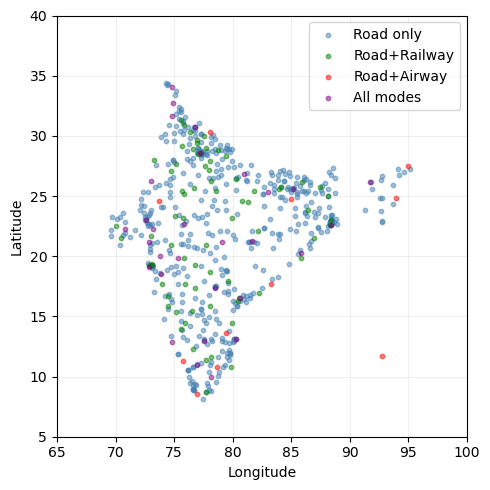

In [435]:
df = import_data(total_data_path)
air_df = import_data(airway_data_path)
rail_df = import_data(railway_data_path)
fc_df = import_data(fc_data_path)
fc_df = df['city']
# df.info()
# air_df.info()
# rail_df.info()
# fc_df.info()
plot_cities(df, air_df, rail_df)

In [415]:
weights = {
    "fuel": 0.3,
    "carbon": 0.2,
    "time": 0.5,
}

### Cost Analysis

In [416]:
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)

Step 1/3: Calculating physical distance matrix...
Step 2/3: Building direct transport cost matrix...


Building transport cost matrix: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 602/602 [00:39<00:00, 15.39it/s]


Step 3/3: Running Floyd-Warshall algorithm...


Running Floyd Warshall algorithm: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 602/602 [00:25<00:00, 23.98it/s]


### Genetic Algorithm

In [479]:
generation_size = 500
reproduction_rate = 0.01
mutation_rate = 0.01
solution_size = fc_df.size
num_generations = 200


Running genetic algorithm:
500 candidates in each generation
Each generation having binary values for 602 FCs


Genetic algorithm: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:53<00:00,  1.15it/s]


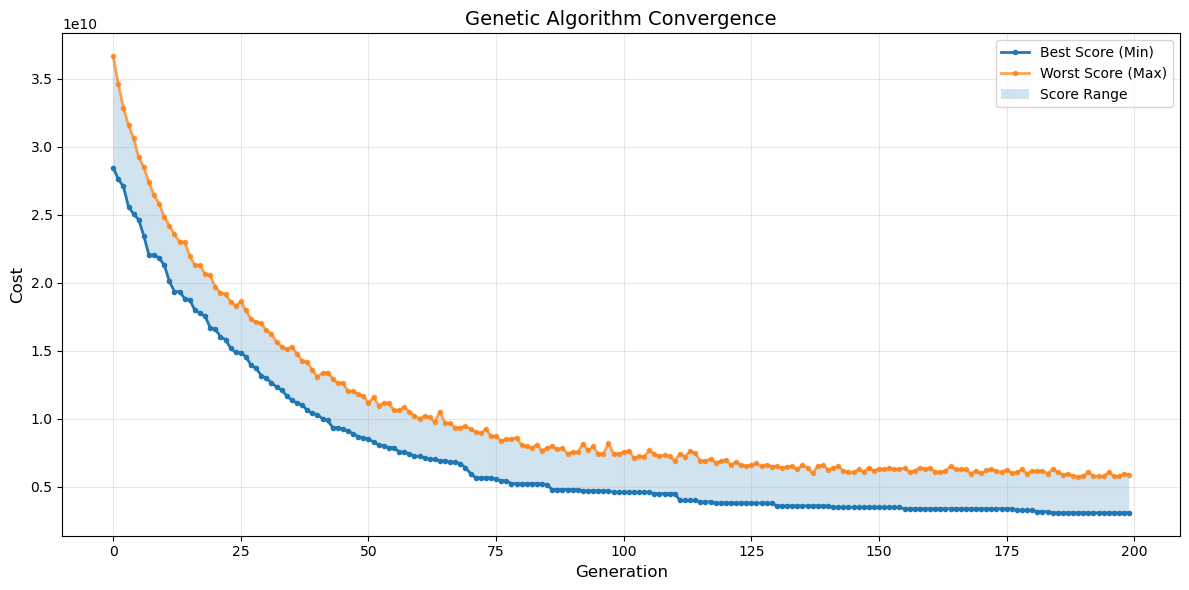

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([3.06311141e+09, 3.18912843e+09, 3.24796357e+09, 3.27388686e+09,
        3.27957105e+09, 3.27977685e+09, 3.29045815e+09, 3.35980803e+09,
        3.36859080e+09, 3.37007828e+09, 3.38159747e+09, 3.38186858e+09,
        3.46639750e+09, 3.46768308e+09, 3.47072754e+09, 3.47383070e+09,
        3.47398287e+09, 3.48108335e+09, 3.48335493e+09, 3.48487672e+09,
        3.49014562e+09, 3.50364763e+09, 3.56702249e+09, 3.56956499e+09,
        3.57498296e+09, 3.57731036e+09, 3.57731036e+09, 3.57793914e+09,
        3.57825067e+09, 3.57873987e+09, 3.57947779e+09, 3.58163361e+09,
        3.60940223e+09, 3.65478817e+09, 3.66792850e+09, 3.67085604e+09,
        3.67354576e+09, 3.67568887e+09, 3.67636113e+09, 3.67636186e+09,
        3.67643844e+09, 3.67789

In [482]:
ga = genetic_algorithm(generation_size = generation_size, 
                  reproduction_rate = reproduction_rate, 
                  mutation_rate = mutation_rate, 
                  solution_size = solution_size,
                  num_generations = num_generations,
                  df = df,
                  fc_df = fc_df)
ga

In [464]:
ans = ga[0][0]
ans

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [470]:
fcd = pd.DataFrame(fc_df['city'].values[ans== 1], columns = ['city'])
fcd

,city
0,Vasai-Virar
1,Nizamabad
2,Bihar
3,Imphal
4,Naihati
5,Dindigul
6,Gadag
7,Thanesar


In [472]:
htc = transport_costs.loc[:,fcd['city'].values]
htc

,Vasai-Virar,Nizamabad,Bihar,Imphal,Naihati,Dindigul,Gadag,Thanesar
Delhi,5.189322e+06,5.184858e+06,4.637648e+06,6.932601e+06,5.723639e+06,7.762182e+06,6.256909e+06,2.417466e+06
Mumbai,1.271500e+07,1.427461e+07,1.692173e+07,1.910116e+07,1.744030e+07,1.578145e+07,1.407731e+07,1.656466e+07
Kolkata,7.613178e+06,6.233138e+06,4.064390e+06,4.679447e+06,2.990316e+06,7.954519e+06,7.380970e+06,6.891476e+06
Bangalore,7.985773e+06,7.302892e+06,9.968896e+06,1.155802e+07,9.965508e+06,6.420038e+06,6.489206e+06,1.078064e+07
Chennai,6.440220e+06,5.334956e+06,7.656542e+06,9.103536e+06,7.544580e+06,4.737432e+06,5.068741e+06,8.811164e+06
...,...,...,...,...,...,...,...,...
Khambhaliya,1.237682e+06,2.670114e+06,4.570656e+06,6.904365e+06,5.345032e+06,4.399043e+06,2.720318e+06,3.107998e+06
Abbigeri,2.416083e+06,1.733202e+06,4.399206e+06,5.988329e+06,4.395818e+06,8.503474e+05,9.195159e+05,5.210945e+06
Kundli,3.165009e+06,3.195213e+06,2.607509e+06,4.821242e+06,3.674088e+06,5.752769e+06,4.203565e+06,3.061067e+05
Sojat,2.003786e+06,2.565550e+06,3.301598e+06,5.651051e+06,4.242348e+06,4.959865e+06,3.286202e+06,1.513354e+06


In [473]:
htc.idxmin(axis = 1)

Delhi             Thanesar
Mumbai         Vasai-Virar
Kolkata            Naihati
Bangalore         Dindigul
Chennai           Dindigul
                  ...     
Khambhaliya    Vasai-Virar
Abbigeri          Dindigul
Kundli            Thanesar
Sojat             Thanesar
Navalyal             Gadag
Length: 602, dtype: object

In [474]:
transport_costs['Suramala']['Abbigeri']

685395.7689967721

In [475]:
next_node['Kundli']['Suramala']

In [476]:
cost_components['Tirupati']['Abbigeri']

{'fuel': 322293.0494400109,
 'carbon': 39966.12864750269,
 'time': 981105.1733333665,
 'mode': <TransportMode.ROAD: 'road'>}

In [312]:
next_node['Delhi']['Tirupati']

In [477]:
calc_network_cost(df, fc_df, ans, transport_costs, cost_components)

(1626674635.6548789,
                       fc
 Delhi           Thanesar
 Mumbai       Vasai-Virar
 Kolkata          Naihati
 Bangalore       Dindigul
 Chennai         Dindigul
 ...                  ...
 Khambhaliya  Vasai-Virar
 Abbigeri        Dindigul
 Kundli          Thanesar
 Sojat           Thanesar
 Navalyal           Gadag
 
 [602 rows x 1 columns])

In [478]:
WAREHOUSE_COST

108000000.0